# 1-2. 신경망(Neural Network)과 MLP (Easy)

| 순서 | 뭘 하나요 | PyTorch 코드 | 이전 챕터에서 배운 것 |
|:---:|----------|-------------|--------------------|
| 1 | 데이터를 텐서로 만들기 | `torch.tensor(...)` | numpy 배열 만들기 |
| 2 | 모델(수식) 만들기 | `nn.Linear(입력, 출력)` | y = ax + b 직접 코딩 |
| 3 | 학습 돌리기 | `model.fit()` 대신 **for문 5줄** | GD for문 직접 코딩 |
| 4 | 예측하기 | `model(새_데이터)` | model.predict() |

| 하고 싶은 것 | Numpy | PyTorch |
|-------------|-------|--------|
| 배열 만들기 | `np.array([1,2,3])` | `torch.tensor([1,2,3])` |
| 덧셈 | `a + b` | `a + b` (동일!) |
| 행렬곱 | `a @ b` | `a @ b` (동일!) |
| 제곱 | `a ** 2` | `a ** 2` (동일!) |
| 합계 | `np.sum(a)` | `torch.sum(a)` |
| 평균 | `np.mean(a)` | `torch.mean(a)` |
| 형태 확인 | `a.shape` | `a.shape` (동일!) |
| 형태 변경 | `a.reshape(-1, 1)` | `a.reshape(-1, 1)` (동일!) |

보시다시피 대부분 **앞에 붙는 이름만 np → torch로 바뀝니다!**

In [12]:
# Pytorch 사용법
import torch

# 왜 numpy가 아니라 torch를 import하나요?
# → 딥러닝에서는 "자동 미분(역전파)"이 필수입니다.
#   Numpy는 자동 미분을 지원하지 않지만, PyTorch의 Tensor는 지원합니다.
#   그래서 딥러닝 = PyTorch Tensor를 써야 합니다.
#   문법은 Numpy와 거의 동일하니까 걱정 마세요!

a = torch.tensor([1, 2, 3])                   # 1차원 텐서 (벡터) ← np.array([1,2,3])과 같음
b = torch.tensor([[1, 2, 3], [4, 5, 6]])       # 2차원 텐서 (행렬) ← np.array([[1,2,3],[4,5,6]])과 같음

print(a)
print(b)
print(f'a의 타입: {type(a)}')  # torch.Tensor (numpy의 ndarray와 비슷한 위치)
print(f'a의 shape: {a.shape}')  # numpy와 동일한 .shape 속성!

tensor([1, 2, 3])
tensor([[1, 2, 3],
        [4, 5, 6]])
a의 타입: <class 'torch.Tensor'>
a의 shape: torch.Size([3])


In [13]:
import numpy as np

# ===== NumPy 방식 (지금까지 써왔던 것) =====
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print('NumPy 행렬곱:', (a + b) @ b)  # 행렬 합과 곱
print()

# ===== PyTorch 방식 (이번 챕터부터 쓸 것) =====
# → 보세요! np.array가 torch.tensor으로 바뀐 것 말고는 코드가 완전히 동일합니다.
#   +, @, **, sum 등 모든 연산이 같은 방식으로 동작합니다.
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])
print('PyTorch 행렬곱:', (a + b) @ b)  # 결과도 동일!

# NumPy
a = np.array([[1, 2], [3, 4]])
print(a ** 2) # 제곱
print(np.sum(a)) # 전체 합

# PyTorch
a = torch.tensor([[1, 2], [3, 4]])
print(a ** 2) # 제곱
print(torch.sum(a)) # 전체 합

# Tensor로 MSE를 직접 구현
# 0-2 챕터에서 배운 MSE를 Tensor 버전으로 구현
# torch.mean() = np.mean()과 같은 역할
def loss(y_hat : torch.Tensor, y : torch.Tensor) :
  return torch.mean((y_hat - y) ** 2)

# 예측값과 실제값
y_hat = torch.tensor([2.5, 0.0, 2.1, 7.8])  # 모델이 예측한 값
y = torch.tensor([3.0, -0.5, 2.0, 7.0])      # 실제 정답

# MSE 출력
print(f'MSE = {loss(y_hat, y).item()}')
print('→ .item()은 텐서에서 숫자 하나를 꺼내주는 메서드입니다.')
print('→ 텐서 상태 그대로 출력하면 tensor(0.2075) 이렇게 나와서, .item()으로 숫자만 꺼냅니다.')


NumPy 행렬곱: [[ 86 100]
 [134 156]]

PyTorch 행렬곱: tensor([[ 86, 100],
        [134, 156]])
[[ 1  4]
 [ 9 16]]
10
tensor([[ 1,  4],
        [ 9, 16]])
tensor(10)
MSE = 0.2875000834465027
→ .item()은 텐서에서 숫자 하나를 꺼내주는 메서드입니다.
→ 텐서 상태 그대로 출력하면 tensor(0.2075) 이렇게 나와서, .item()으로 숫자만 꺼냅니다.


In [14]:
# Autograd 기능
# 경사 하강법을 하려면 매 스텝마다 미분을 해야함
# PyTorch의 자동 미분을 켜면 연산할 때마다 계산 그래프를 함께 기록



# 왜 requires_grad=True를 설정하나요?
# → 이 텐서에 대해 "미분 추적 기능"을 켜겠다는 뜻입니다.
#   이후 이 텐서를 포함한 모든 연산은 미분할 준비가 됩니다.
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x + 1  # 이 연산을 할 때, 빠른 미분을 위한 내부 기록도 함께 이뤄집니다.

# 왜 backward()를 호출하나요?
# → "지금까지 기록해둔 정보를 바탕으로, 미분값을 계산해줘!"라는 명령입니다.
#   이것이 바로 '역전파(Backpropagation)'의 핵심입니다.
y.backward()
print(x.grad)  # dy/dx = 2x + 3 = 2*2 + 3 = 7.0


# 왜 torch.no_grad()로 끄나요?
# → 평가할 때는 미분이 필요 없습니다. 켜두면 메모리만 낭비!
with torch.no_grad():  # 이 블록 안에서는 미분 추적 OFF
  y = x ** 2 + 5*x + 10  # 내부 미분 기록 안 함 → 메모리 절약
  #y.backward()  # 에러 발생! (추적을 안 했으니 미분 불가)

# 다시 여기서부터는 미분 추적 기능이 ON 됩니다.
y = x ** 2 + 4*x + 1
y.backward()
print(x.grad)  # 주의: 기울기 값이 앞에 있었던 7에 자동 누적됩니다! (7.0 + 8.0 = 15.0)

# 왜 zero_()를 호출하나요?
# → grad 값이 계속 누적되기 때문에, 새로 계산하려면 먼저 0으로 초기화해야 합니다.
#   안 하면 이전 미분값이 섞여서 잘못된 결과가 나옵니다!
x.grad.zero_()
y = x ** 2 + 4*x + 1
y.backward()
print(x.grad)  # 초기화 후 다시 계산 → 2*2 + 4 = 8.0

# 미분 추적 기능은 학습할 때부터 ON
# 중간 평가(Validation)과 최종평가(Test)할 때 OFF
# 시각화 할 때도 OFF


tensor(7.)
tensor(15.)
tensor(8.)


Epoch [500/2000], Loss: 1.0360
Epoch [1000/2000], Loss: 1.0360
Epoch [1500/2000], Loss: 1.0360
Epoch [2000/2000], Loss: 1.0360


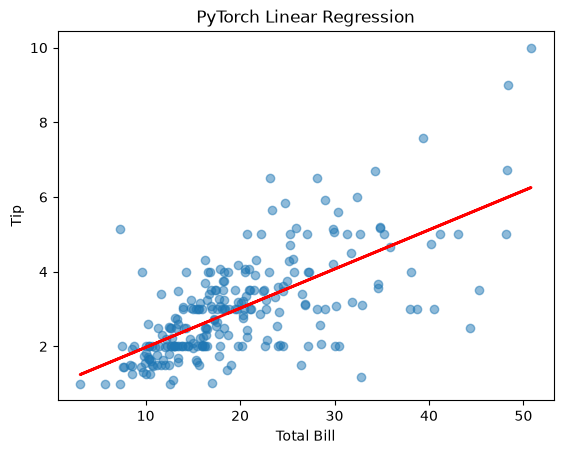

In [15]:
import torch
# 왜 torch.nn을 import하나요?
# → nn = Neural Network의 줄임말. 모델(레이어)을 만드는 도구가 들어있습니다.
#   nn.Linear, nn.ReLU, nn.Sequential 등이 여기에 있습니다.
import torch.nn as nn

# 왜 torch.optim을 import하나요?
# → optim = Optimizer의 줄임말. 학습 알고리즘이 들어있습니다.
#   optim.SGD(기본 GD), optim.Adam(똑똑한 GD) 등이 여기에 있습니다.
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

# ========== 1. 데이터 준비 ==========
tips = sns.load_dataset('tips')

# 왜 dtype=torch.float32를 쓰나요?
# → PyTorch 모델은 float32 타입으로 연산합니다.
#   pandas 데이터는 float64일 수 있어서, 맞춰주지 않으면 에러납니다.
# 왜 reshape(-1, 1)을 하나요?
# → nn.Linear는 입력을 2차원 행렬로 받습니다. (Scikit-learn도 같았죠!)
X = torch.tensor(tips['total_bill'].values, dtype=torch.float32).reshape(-1, 1)
y = torch.tensor(tips['tip'].values, dtype=torch.float32).reshape(-1, 1)

# ========== 2. 모델 만들기 ==========
# Scikit-learn: model = LinearRegression()
# PyTorch:      model = nn.Linear(입력수, 출력수)
# → 입력 1개(total_bill), 출력 1개(tip) → nn.Linear(1, 1)
# → 이 한 줄로 y = wx + b 수식이 만들어집니다. w, b는 랜덤으로 초기화됨!
model = nn.Linear(1, 1)

# ========== 3. 손실함수 & 옵티마이저 정의 ==========
# 왜 따로 만드나요?
# → Scikit-learn은 fit() 안에 전부 숨겨져 있었지만,
#   PyTorch는 "얼마나 틀렸는지 측정하는 함수"와 "어떻게 업데이트할지"를 직접 지정합니다.
#   이렇게 하면 상황에 맞게 MSE↔CrossEntropy, SGD↔Adam을 바꿀 수 있습니다!
criterion = nn.MSELoss()  # 손실함수: MSE (0-2 챕터에서 배움)
optimizer = optim.SGD(model.parameters(), lr=0.001)  # 옵티마이저: 기본 GD
# model.parameters() → 모델 안의 w, b를 옵티마이저에게 넘겨주는 것
# lr=0.001 → 학습률 (0-2 챕터에서 배운 점프 거리)

# ========== 4. 학습 루프 (핵심!) ==========
# 0-2 챕터에서 for문으로 GD를 직접 코딩했었죠?
# PyTorch에서는 5줄로 동일한 일을 합니다.
for epoch in range(2000):  # 2000번 반복 (= 2000번 점프)
    y_hat = model(X)               # ① 순전파: 현재 w, b로 예측
    loss = criterion(y_hat, y)      # ② 손실 계산: 예측값과 정답의 MSE
    optimizer.zero_grad()           # ③ 기울기 초기화 (왜? 안 하면 이전 값이 누적!)
    loss.backward()                 # ④ 역전파: 미분값 자동 계산 (이게 Autograd의 힘!)
    optimizer.step()                # ⑤ 업데이트: 계산된 기울기로 w, b 한 스텝 조정

    if (epoch + 1) % 500 == 0:
        print(f'Epoch [{epoch+1}/2000], Loss: {loss.item():.4f}')

# ========== 5. 결과 확인 ==========
# 왜 torch.no_grad()를 쓰나요?
# → 시각화할 때는 학습(역전파)이 필요 없으니, 미분 추적을 끕니다.
#   끄면 메모리 절약 + 속도 향상!
with torch.no_grad():
    y_hat = model(X)

plt.scatter(X.numpy(), y.numpy(), alpha=0.5)
# .numpy() → 텐서를 다시 numpy 배열로 변환 (matplotlib은 numpy를 원하니까)
plt.plot(X.numpy(), y_hat.numpy(), color='red', linewidth=2)
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('PyTorch Linear Regression')
plt.show()


Epoch   0 | Loss: 3.0768
Epoch 100 | Loss: 0.3854
Epoch 200 | Loss: 0.3035
Epoch 300 | Loss: 0.2549
Epoch 400 | Loss: 0.2228
학습완료



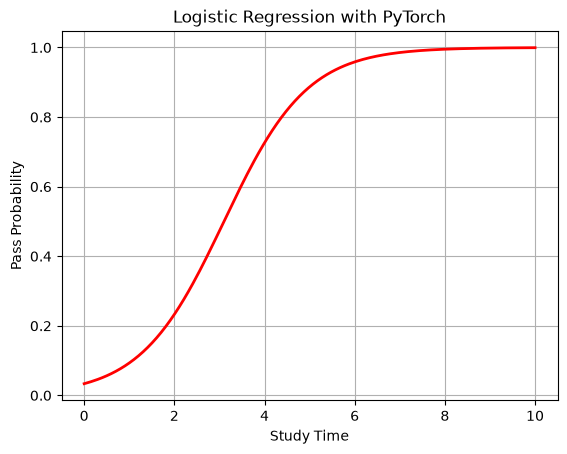

In [17]:
## 함수 중첩 = sequential model. 시그모이드 표현 가능 
# model = nn.Sequential(

#     nn.Linear(1, 1),   # 1번 블록: y = wx + b 계산. 직선 그리기
#     nn.Sigmoid()       # 2번 블록: 결과를 0~1 사이 확률로 변환. 직선을 S자로 구부리
# ) 

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 공부 시간 (입력)
# reshape 없이 [[1.0], [2.0], ...] 형태로 바로 만든 이유는?
# -> nn.Linear는 입력을 (샘플수, 특성수) 2차원으로 받기 때문입니다.
#    여기서는 (29, 1) 이 됩니다. 샘플 29개, 특성 1개(공부시간).
X = torch.tensor([
    [1.0], [2.0], [3.0], [4.0], [5.0], [6.0],
    [2.0], [3.0], [4.0], [5.0], [6.0], [7.0],
    [1.0], [2.0], [3.0], [4.0], [5.0], [6.0],
    [7.0], [8.0], [2.0], [3.0], [4.0], [5.0],
    [6.0], [7.0], [8.0], [9.0], [10.0]
])

# 합격 여부 (0 : 불합격, 1 : 합격)
# 왜 0/1을 float으로 넣나요?
# -> BCELoss는 정답을 확률(0.0 ~ 1.0)로 취급하기 때문에 float이어야 합니다.
#    (뒤에 나올 CrossEntropyLoss는 반대로 정수(long) 레이블을 받습니다. 헷갈리지 마세요!)
y = torch.tensor([
    [0.0], [0.0], [0.0], [1.0], [1.0], [1.0],
    [0.0], [0.0], [1.0], [1.0], [1.0], [1.0],
    [0.0], [0.0], [0.0], [1.0], [1.0], [1.0],
    [1.0], [1.0], [0.0], [0.0], [1.0], [1.0],
    [1.0], [1.0], [1.0], [1.0], [1.0]
])

# [중요] 아래 모델은 sigmoid(wx + b) 가 됩니다.
# 블록 1 (nn.Linear)  : 점수를 계산  -> 범위 제한 없음 (-무한대 ~ +무한대)
# 블록 2 (nn.Sigmoid) : 점수를 확률로 압축 -> 0 ~ 1
model = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)

# BCELoss = Binary Cross Entropy. 이진 분류(합격/불합격) 전용 손실 함수입니다.
# [주의] BCELoss는 입력이 반드시 0~1 확률이어야 합니다.
#        -> 그래서 위 모델에 nn.Sigmoid()가 꼭 있어야 합니다. 빼면 에러가 납니다!
criterion = nn.BCELoss() # Binary 크로스 엔트로피 손실 함수
optimizer = optim.SGD(model.parameters(), lr=0.1) # GD 사용

for epoch in range(500):
    y_hat = model(X)                # 1. 순전파 : 현재 w, b로 합격 확률 예측

    loss = criterion(y_hat, y)      # 2. 손실 계산 : 정답에 얼마나 확신했나

    optimizer.zero_grad() # 초기화    (누적된 이전 기울기 지우기)
    loss.backward() # 미분 계산       # 3. 역전파 : 각 w, b의 책임 계산

    optimizer.step() # 학습 (w, b 값 업데이트)   # 4. 업데이트

    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print('학습완료')

# 예측 선 준비
with torch.no_grad():  # 시각화용이므로 미분 추적 OFF
  # linspace(0, 10, 200) = 0부터 10까지 200등분한 값. 부드러운 곡선을 그리기 위함.
  x_line = torch.linspace(0, 10, 200).reshape(-1, 1)
  y_line = model(x_line)

  # 시각화
  plt.plot(x_line.numpy(), y_line.numpy(), color='red', linewidth=2)
  plt.title("Logistic Regression with PyTorch")
  plt.xlabel("Study Time")
  plt.ylabel("Pass Probability")
  plt.grid(True)
  print()

# [확인 포인트] 그려진 빨간 곡선이 S자 모양인가요?
#   - 공부시간이 적으면 확률이 0에 가깝고
#   - 많으면 1에 가까워지며
#   - 중간 어딘가에서 가파르게 올라갑니다. 그 지점이 '결정 경계'입니다.



> | 문제 유형 | 출력층 활성화 | 손실 함수 | 주의사항 |
> |---|---|---|---|
> | 회귀 (숫자 맞히기) | 없음 | `nn.MSELoss()` | |
> | 이진 분류 | **`nn.Sigmoid()`** | `nn.BCELoss()` | Sigmoid **필수** (위 코드가 이 방식) |
> | 이진 분류 (권장) | **없음** | `nn.BCEWithLogitsLoss()` | Sigmoid 내장 + 수치적으로 더 안정 |
> | 다중 분류 | **없음** | `nn.CrossEntropyLoss()` | **Softmax 내장!** 따로 넣으면 안 됨 |
>
> **실수 1위**
> 뒤에 나올 MNIST 모델은 마지막이 `nn.Linear(128, 10)` 으로 그냥 끝납니다.
> Softmax를 빠뜨린 게 아니라, **`CrossEntropyLoss` 안에 이미 들어 있어서 일부러 뺀 것**입니다.
> 여기에 `nn.Softmax()` 를 또 붙이면 **이중 적용되어 학습이 망가집니다.**
>
> 💡 Softmax를 통과하기 **전**의 날것 점수를 **logits(로짓)** 이라고 부릅니다.
> 실습 코드에서 `outputs`, `logits` 라는 변수명이 나오면 "아직 확률이 아니구나"로 읽으시면 됩니다.

Epoch     0 | Loss: 37.352737
Epoch   500 | Loss: 0.042267
Epoch  1000 | Loss: 0.032520
Epoch  1500 | Loss: 0.022838
Epoch  2000 | Loss: 0.017506
Epoch  2500 | Loss: 0.012673
Epoch  3000 | Loss: 0.007860
Epoch  3500 | Loss: 0.008827
Epoch  4000 | Loss: 0.004278
Epoch  4500 | Loss: 0.005949
Epoch  5000 | Loss: 0.004276
Epoch  5500 | Loss: 0.003199
Epoch  6000 | Loss: 0.001316
Epoch  6500 | Loss: 0.004213
Epoch  7000 | Loss: 0.004815
Epoch  7500 | Loss: 0.007786
Epoch  8000 | Loss: 0.005282
Epoch  8500 | Loss: 0.001578
Epoch  9000 | Loss: 0.002707
Epoch  9500 | Loss: 0.001158



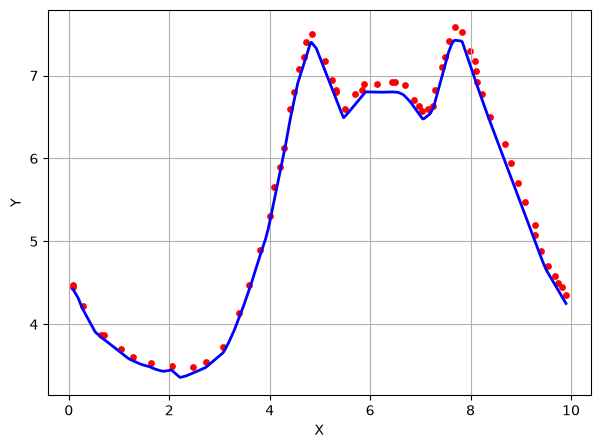

In [18]:
# 비선형 방정식 만들기
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 고양이 좌표
data = torch.tensor([
    [0.65, 3.87],[0.08, 4.47],[0.08, 4.45],[0.28, 4.22],[0.70, 3.87],
    [1.03, 3.70],[1.28, 3.60],[1.63, 3.53],[2.05, 3.50],[2.48, 3.48],
    [2.73, 3.55],[3.08, 3.73],[3.38, 4.13],[3.58, 4.47],[3.80, 4.90],
    [4.00, 5.30],[4.08, 5.65],[4.20, 5.90],[4.28, 6.13],[4.40, 6.60],
    [4.48, 6.80],[4.58, 7.08],[4.68, 7.22],[4.73, 7.40],[4.85, 7.50],
    [5.10, 7.18],[5.25, 6.95],[5.33, 6.83],[5.33, 6.80],[5.50, 6.60],
    [5.70, 6.78],[5.83, 6.83],[5.88, 6.90],[6.13, 6.90],[6.43, 6.92],
    [6.50, 6.92],[6.70, 6.88],[6.88, 6.70],[6.98, 6.63],[7.03, 6.57],
    [7.30, 6.83],[7.43, 7.10],[7.50, 7.22],[7.58, 7.42],[7.68, 7.58],
    [7.15, 6.60],[7.25, 6.63],[7.83, 7.52],[7.98, 7.30],[8.08, 7.18],
    [8.10, 7.05],[8.13, 6.92],[8.23, 6.78],[8.38, 6.50],[8.68, 6.17],
    [8.80, 5.95],[8.95, 5.70],[9.08, 5.47],[9.28, 5.20],[9.28, 5.08],
    [9.40, 4.88],[9.55, 4.70],[9.68, 4.58],[9.75, 4.50],[9.83, 4.45],
    [9.90, 4.35]
], dtype=torch.float32)

# 입력(X), 출력(y)
X = data[:, [0]]
y = data[:, [1]]

# 모델 정의 (비선형 MLP)
model = nn.Sequential(
    nn.Linear(1, 64), # Layer 0, 입력은 1개, 출력은 64개
    nn.ReLU(),
    nn.Linear(64, 128), # Layer 1, 입력은 64개, 출력은 128개
    nn.ReLU(),
    nn.Linear(128, 128), # Layer 2, 입력은 128개, 출력 128개
    nn.ReLU(),
    nn.Linear(128, 1) # Layer 3, 최종 출력은 1개
)

# 손실함수 & 옵티마이저
criterion = nn.MSELoss()
#optimizer = optim.SGD(model.parameters(), lr=0.01) # GD
optimizer = optim.Adam(model.parameters(), lr=0.005) # 그냥 GD 보다 Adam 이 성능이 더 잘나와요.

# 학습 루프
for epoch in range(10000):
    y_pred = model(X)
    loss = criterion(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f}")

# 예측 곡선 생성
with torch.no_grad():
  x_line = torch.linspace(X.min(), X.max(), 400).reshape(-1, 1)
  y_line = model(x_line)

  # 시각화
  plt.figure(figsize=(7,5))
  plt.scatter(X.numpy(), y.numpy(), color='red', s=15)
  plt.plot(x_line.numpy(), y_line.numpy(), color='blue', linewidth=2)
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.grid(True)
  print()


Epoch     0 | Loss: 24.289394
Epoch  1000 | Loss: 0.521406
Epoch  2000 | Loss: 0.303109
Epoch  3000 | Loss: 0.101137
Epoch  4000 | Loss: 0.049698
Epoch  5000 | Loss: 0.034884
Epoch  6000 | Loss: 0.025659
Epoch  7000 | Loss: 0.018744
Epoch  8000 | Loss: 0.014029
Epoch  9000 | Loss: 0.011874
Epoch 10000 | Loss: 0.011025
Epoch 11000 | Loss: 0.010670
Epoch 12000 | Loss: 0.010466
Epoch 13000 | Loss: 0.010350
Epoch 14000 | Loss: 0.010275



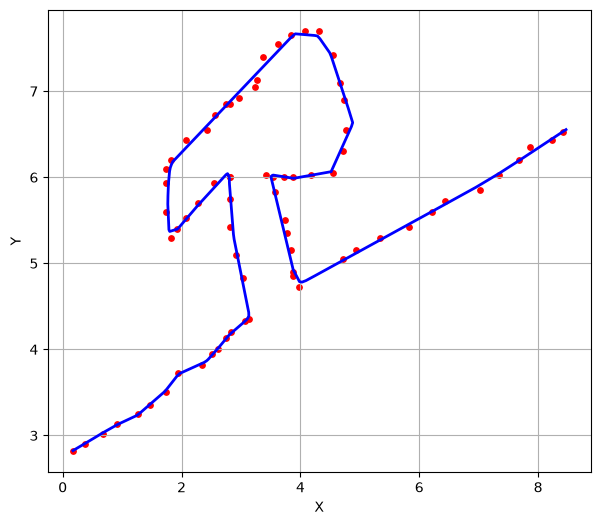

In [20]:
# 매개변수 곡선 만들기

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 치킨 좌표
data = torch.tensor([
    [0.17, 2.82], [0.37, 2.90], [0.67, 3.02], [0.92, 3.13], [1.27, 3.25],
    [1.47, 3.35], [1.74, 3.50], [1.94, 3.73], [2.34, 3.82], [2.52, 3.95],
    [2.62, 4.00], [2.74, 4.13], [2.84, 4.20], [3.07, 4.33], [3.14, 4.35],
    [3.04, 4.83], [2.92, 5.10], [2.82, 5.42], [2.82, 5.75], [2.82, 6.00],
    [2.82, 6.00], [2.54, 5.93], [2.27, 5.70], [2.07, 5.53], [1.92, 5.40],
    [1.82, 5.30], [1.74, 5.60], [1.74, 5.93], [1.74, 6.10], [1.82, 6.20],
    [2.07, 6.43], [2.57, 6.72], [2.74, 6.85], [2.82, 6.85], [2.97, 6.92],
    [3.24, 7.05], [2.42, 6.55], [3.27, 7.13], [3.37, 7.40], [3.62, 7.55],
    [3.84, 7.65], [4.07, 7.70], [4.32, 7.70], [4.54, 7.42], [4.67, 7.10],
    [4.74, 6.90], [4.77, 6.55], [4.72, 6.30], [4.54, 6.05], [4.17, 6.03],
    [3.87, 6.00], [3.72, 6.00], [3.54, 6.00], [3.42, 6.03], [3.57, 5.83],
    [3.74, 5.50], [3.77, 5.35], [3.84, 5.15], [3.87, 4.90], [3.87, 4.85],
    [3.97, 4.73], [4.72, 5.05], [4.94, 5.15], [5.34, 5.30], [5.82, 5.42],
    [6.22, 5.60], [6.44, 5.72], [7.02, 5.85], [7.34, 6.03], [7.67, 6.20],
    [7.87, 6.35], [8.24, 6.43], [8.42, 6.53]
], dtype=torch.float32)

# 입력 = t, 출력 = (x, y)
t = torch.linspace(0, 1, len(data)).reshape(-1, 1)
X_target = data  # 출력 목표: (x, y)

# 모델 정의
model = nn.Sequential(
    nn.Linear(1, 128), # layer 0, 첫 입력은 1개 (t)
    nn.ReLU(),
    nn.Linear(128, 128), # Layer 1
    nn.ReLU(),
    nn.Linear(128, 128), # Layer 2
    nn.ReLU(),
    nn.Linear(128, 2) # Layer 3, 최종 출력은 2개 (x, y)
)

# 학습 설정
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 학습
for epoch in range(15000):
    X_pred = model(t)
    loss = criterion(X_pred, X_target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f}")


# 예측 선 생성
with torch.no_grad():
  t_dense = torch.linspace(0, 1, 400).reshape(-1, 1)
  pred_curve = model(t_dense)

  # 시각화
  plt.figure(figsize=(7,6))
  plt.scatter(X_target[:,0], X_target[:,1], color='red', s=15)
  plt.plot(pred_curve[:,0], pred_curve[:,1], color='blue', linewidth=2)
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.grid(True)
  print()

## 여기서부터 과제 1-2 간단한 perceptron 구현 

In [ ]:
#환경 설정
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 재현성을 위한 시드 고정
# 신경망의 가중치는 '무작위'로 초기화됩니다. (교재 3장 순전파 1번 참고)
# 시드를 고정하지 않으면 실행할 때마다 초기값이 달라져서 결과가 매번 바뀝니다.
# 교육/디버깅 상황에서는 항상 고정해두는 것이 좋습니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)      # NumPy 난수 고정 (데이터 생성/분할에 영향)
torch.manual_seed(RANDOM_STATE)   # PyTorch CPU 난수 고정 (가중치 초기화에 영향)

In [25]:
#Todo1: autogra 매커니즘 실습
# 입력과 목표값
# x, y_true는 '데이터'입니다. 학습 중에 바뀌지 않으므로 requires_grad가 필요 없습니다.
x = torch.tensor([[3.0]])
y_true = torch.tensor([[8.0]])

# 1. 파라미터 `w`와 `b`를 생성해주세요.
# 미분을 사용하기 위해서는 `requires_grad=True`로 생성해야하겠죠?
# 값은 임의로 초기화 해주세요.
#   -> requires_grad=True 는 "이 텐서에 가해지는 모든 연산을 추적해라"는 신호입니다.
#      추적해두어야 나중에 backward()로 거꾸로 되짚어갈 수 있습니다.
w = torch.tensor([[2.0]], requires_grad=True)
b = torch.tensor([[1.0]], requires_grad=True)

# 2. 순전파 `y_pred`를 계산해주세요.  <- 교재 학습 4단계의 (1) 순전파
y_pred = w * x + b

# 3. 현재 파라미터 `w`와 `b`에 대한 Mean squared error 손실을 계산해 `loss`에 할당해주세요.
#    <- 교재 학습 4단계의 (2) 손실 계산. MSE = (예측 - 정답)의 제곱 평균
loss = ((y_pred - y_true) ** 2).mean()

# 4. `.backward`를 통해 역전파를 수행합니다.  <- 교재 학습 4단계의 (3) 역전파
#    이 한 줄이 w.grad, b.grad를 채워줍니다. (호출 전에는 둘 다 None)
loss.backward()

print(f"예측값: {y_pred.item():.2f}")
print(f"손실: {loss.item():.2f}")
print(f"w의 기울기: {w.grad.item():.2f}")
print(f"b의 기울기: {b.grad.item():.2f}")


예측값: 7.00
손실: 1.00
w의 기울기: -6.00
b의 기울기: -2.00


In [26]:
#TODO 2: 데이터셋 생성 및 전처리
# 데이터 생성
# make_moons: 초승달 두 개가 맞물린 모양의 2차원 데이터.
#   noise=0.2 -> 점들을 살짝 흩뿌려 현실적인 난이도를 만듭니다.
#   이 데이터는 '직선 하나로는 나눌 수 없는' 대표적인 비선형 문제입니다. (교재의 XOR과 같은 맥락)
X, y = make_moons(n_samples=1000, noise=0.2, random_state=RANDOM_STATE)

# 1. 훈련과 검증 데이터를 80%/20%으로 분할해주세요.
#   stratify=y -> 훈련/검증 양쪽의 클래스 비율을 원본과 동일하게 유지합니다.
#                 (한쪽에 0만 몰리는 사고를 막아줍니다)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 2. `sklearn.preprocessing.StandardScaler`를 통한 표준화를 진행해주세요.
#   표준화 = 각 특성을 평균 0, 표준편차 1로 맞추는 작업.
#   왜 필요한가? 특성마다 값의 범위가 다르면 학습이 요동칩니다.
#   ⚠️ fit_transform은 '훈련 데이터에만', 검증 데이터에는 transform만! (아래 callout 참고)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # 기준(평균/표준편차)을 '학습'하고 변환
X_valid = scaler.transform(X_valid)      # 위에서 학습한 기준을 그대로 '적용'만

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Valid set: {X_valid.shape}, {y_valid.shape}")


Train set: (800, 2), (800,)
Valid set: (200, 2), (200,)


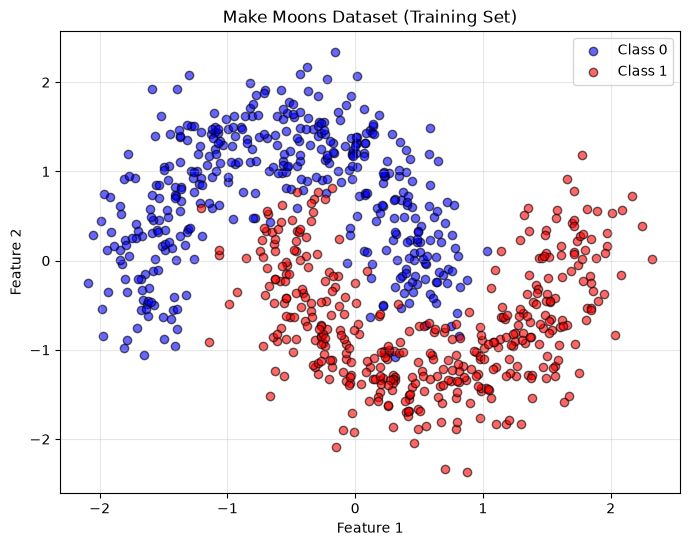

In [27]:
#데이터 시각화 
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c='blue', label='Class 0', alpha=0.6, edgecolors='k')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='red', label='Class 1', alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Make Moons Dataset (Training Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
#Todo3: PyTorch Tensor 변환 및 DataLoader 생성
# 1. NumPy 배열을 PyTorch Tensor로 변환해주세요.
#   특성(X)은 float32, 라벨(y)은 int64(long)로 맞춰야 합니다.
#   왜? -> nn.Linear의 가중치가 float32라서 입력도 float32여야 하고,
#         CrossEntropyLoss는 정답을 '몇 번째 클래스인가'라는 정수 인덱스로 받기 때문입니다.
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).long()
X_valid_t = torch.from_numpy(X_valid).float()
y_valid_t = torch.from_numpy(y_valid).long()

# 2. 1에서 변환한 Tensor를 통해 TensorDataset을 생성해주세요.
#   TensorDataset: (X, y)를 한 쌍으로 묶어주는 상자. dataset[0] -> (X[0], y[0])
train_dataset = TensorDataset(X_train_t, y_train_t)
valid_dataset = TensorDataset(X_valid_t, y_valid_t)

# 3. 2에서 생성한 Dataset으로 DataLoader를 생성합니다.
#   DataLoader: 상자에서 batch_size개씩 꺼내주는 자동 공급기.
#   shuffle=True  (훈련) -> 매 에포크마다 순서를 섞어 '순서 암기'를 방지
#   shuffle=False (검증) -> 섞을 이유가 없고, 결과 비교를 위해 순서를 고정
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# len(loader)는 데이터 개수가 아니라 '배치 개수'입니다. (800 / 32 = 25)
print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")

# 첫 번째 배치 확인
# DataLoader는 인덱싱(loader[0])이 안 되므로 iter()로 감싸서 next()로 하나 꺼냅니다.
x_batch, y_batch = next(iter(train_loader))
print(f"\n첫 번째 배치 - X shape: {x_batch.shape}, y shape: {y_batch.shape}")


Train batches: 25
Valid batches: 7

첫 번째 배치 - X shape: torch.Size([32, 2]), y shape: torch.Size([32])


In [29]:
# ToDo4: 퍼셉트론 모델 구현
class SimplePerceptron(nn.Module):
    """2차원 입력을 받아 이진 분류를 수행하는 단순 신경망입니다.

    구조: 입력(2) -> Linear -> ReLU -> Linear -> 출력(2)
    은닉층이 하나 있으므로 엄밀히는 '다층 퍼셉트론(MLP)'입니다.
    은닉층 덕분에 직선 하나로 못 나누는 초승달 데이터도 분류할 수 있습니다.

    Args:
        input_dim (int): 입력 특성 수. make_moons는 2차원이므로 2
        hidden_dim (int): 은닉층 뉴런 수. 클수록 표현력이 커지지만 과적합 위험도 커짐
        output_dim (int): 출력 클래스 수. 이진 분류이므로 2
    """

    def __init__(self, input_dim=2, hidden_dim=16, output_dim=2):
        super().__init__()  # nn.Module의 생성자. 빼먹으면 파라미터 등록이 안 됩니다.

        # 1. 주어진 `SimplePerceptron`의 인자에 맞춰 `__init__`에 모델을 구현해주세요
        #    __init__은 '부품 목록'입니다. 여기서는 조립하지 않고 선언만 합니다.
        self.fc1 = nn.Linear(input_dim, hidden_dim)   # 선형 변환 (내부에 w와 b가 함께 생성됨)
        self.relu = nn.ReLU()                          # 비선형성 = 교재의 '종이를 접는 손'
        self.fc2 = nn.Linear(hidden_dim, output_dim)   # 출력층 (Softmax 없음! 아래 callout 참고)

    def forward(self, x):
        # 2. `forward`에서 1.1의 로직대로 순전파를 수행해주세요.
        #    forward는 '조립 설명서'입니다. 부품을 어떤 순서로 통과시킬지 정합니다.
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


# 모델 생성 및 테스트
model = SimplePerceptron(input_dim=2, hidden_dim=16, output_dim=2)
print(model)

# 더미 입력으로 테스트
# 실제 데이터를 넣기 전에 '가짜 데이터'로 shape이 맞는지 먼저 확인하는 습관을 들이세요.
# 딥러닝 디버깅의 대부분은 shape 문제입니다.
dummy_input = torch.randn(5, 2)   # (데이터 5개, 특성 2개)
output = model(dummy_input)
print(f"\nInput shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")   # (5, 2) = 데이터 5개 x 클래스 2개 점수


SimplePerceptron(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)

Input shape: torch.Size([5, 2])
Output shape: torch.Size([5, 2])


In [ ]:
#TODO 5 : Loss Function 과 Optimizer 정의
# 1. TODO 4에서 여러분이 직접 만든 모델을 선언하고 가속화기기로 보내줍니다.
#   ⚠️ 여기서 모델을 '새로' 만들기 때문에 가중치가 다시 무작위로 초기화됩니다.
#      (위 TODO 4에서 만든 모델과는 다른 객체입니다)
#   .to(device) -> 모델의 모든 가중치를 GPU(또는 CPU)로 옮깁니다.
model = SimplePerceptron(input_dim=2, hidden_dim=16, output_dim=2).to(device)

# 2. `torch.nn.CrossEntropyLoss`를 통해 `criterion`을 선언해줍니다.
#   교차 엔트로피 = '정답에 얼마나 확신했는가'를 재는 성적표 (교재 3장 2단계)
#   내부에 Softmax가 이미 포함되어 있습니다. 그래서 모델 마지막에 Softmax를 넣지 않았습니다.
criterion = nn.CrossEntropyLoss()

# 3. Adam optimizer를 선언해줍니다. 학습률은 주어진 `LR`을 사용해주세요.
#   model.parameters()를 넘기는 순간, 이 모델의 모든 w와 b가 옵티마이저의 관리 대상이 됩니다.
#   LR(학습률) = 한 걸음의 보폭. 너무 크면 발산, 너무 작으면 학습이 느립니다.
LR = 0.01
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"Model: {model}")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
